# Why do we even dropout layers and how does it work in anns' ?
Dropout is a regularization technique for reducing overfitting in artificial neural networks by preventing complex co-adaptations on training data. The technique consists of randomly setting the inputs and/or outputs of neurons to zero. It is performed during the training process of a neural network, not during inference.


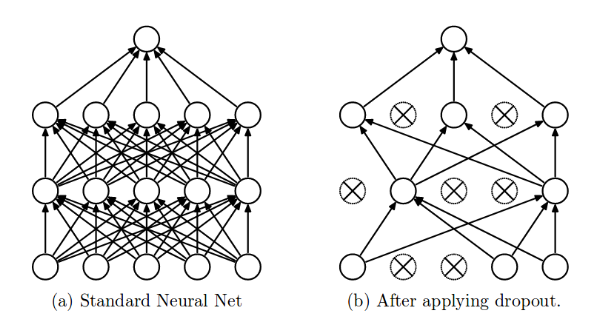

This can be correlated with random forest algorithm in machine learning where we train hundreds of tree based of randomly selecting columns , rows or both to form decision tree and then predicting using crowd's wisdom

In [1]:
# First import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input
from tensorflow.keras.optimizers import Adam

In [2]:
# Load the artificial dataset
df = pd.read_csv('artificial-dataset-classification.csv')

In [3]:
df.head() # Skim the head

,Feature_1,Feature_2,Target
0,-0.158986,0.423977,1
1,-0.347926,0.470760,1
2,-0.504608,0.353801,1
3,-0.596774,0.114035,1
4,-0.518433,-0.172515,1


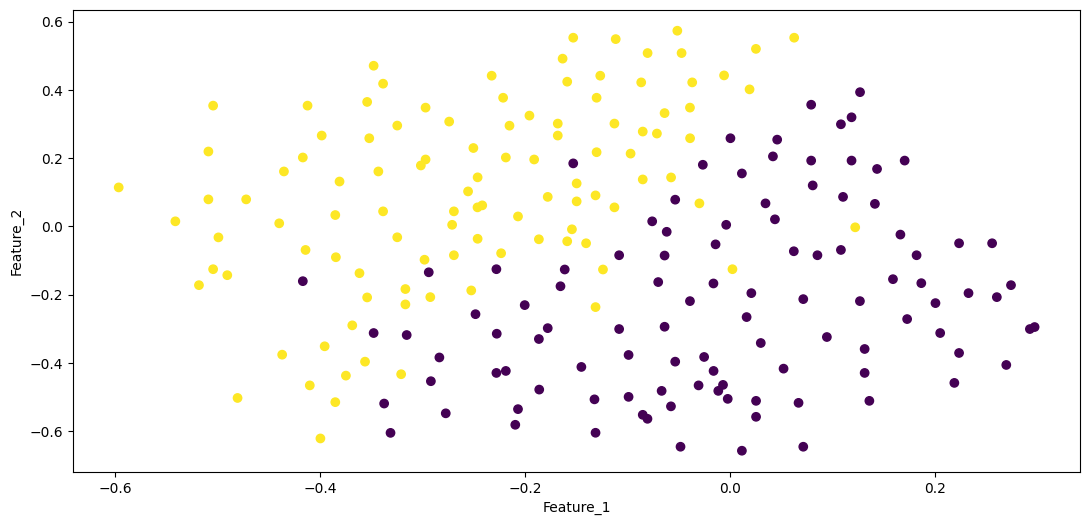

In [4]:
plt.figure(figsize=(13,6))
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=df.iloc[:,-1])
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.show()

In [5]:
# Now splitting the dataset into X and y 
X,y = df.iloc[:,:-1],df.iloc[:,-1]

In [6]:
# Our model will have hidden layers as relu and the final ouptut layer will have the activation function as sigmoid
# And we will be using binary_crossentropy as loss function with adam as optimizer with the learning rate of 0.1 
# Now commencing the creation of model

In [9]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [10]:
# Now let's skim the summary to know what amount of parameters we are dealing with
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# We will explicitly pass adam this time with a learning rate of 0.1
adam = Adam(learning_rate=0.1)

In [13]:
# Now let's compile the model
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

In [14]:
# Now lets run the model
history = model.fit(X,y,epochs=500,validation_split=0.2,verbose=1)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.7143 - loss: 0.7513 - val_accuracy: 0.6047 - val_loss: 0.7011
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8750 - loss: 0.2813 - val_accuracy: 0.5814 - val_loss: 0.7163
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8690 - loss: 0.2411 - val_accuracy: 0.7442 - val_loss: 0.5984
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9226 - loss: 0.2046 - val_accuracy: 0.8605 - val_loss: 0.4392
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9345 - loss: 0.2071 - val_accuracy: 0.8605 - val_loss: 0.5325
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9226 - loss: 0.1852 - val_accuracy: 0.8605 - val_loss: 0.7359
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9286 - loss: 0.1863 - val_accuracy: 0.8605 - val_loss: 0.7769
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9405 - loss: 0.1742 - val_accuracy: 0.8837 - val_los

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step


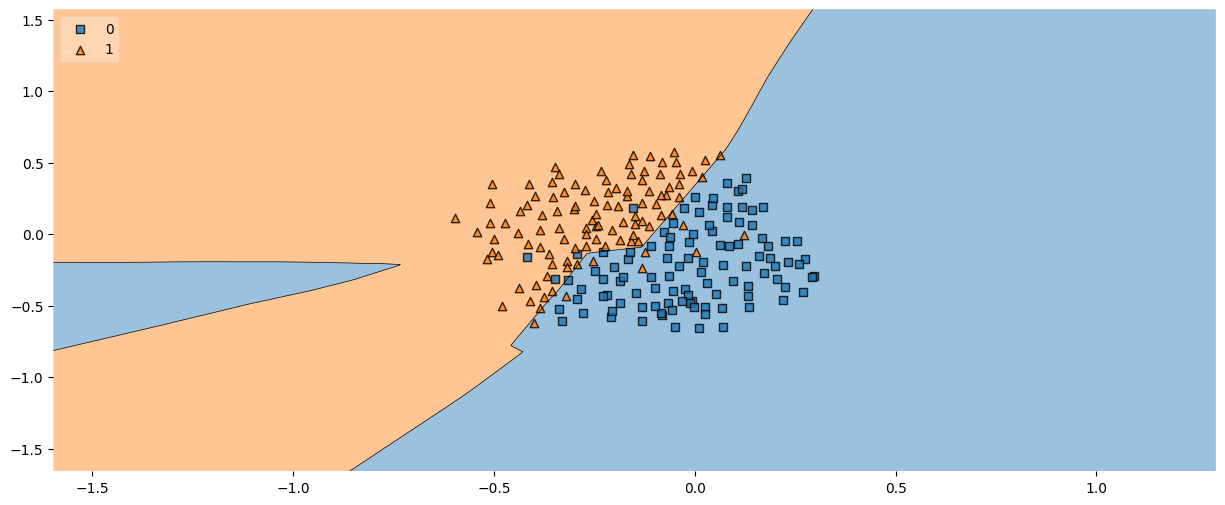

In [18]:
# Now let's checkout the model performance by plotting it's boundary using plot_decision_regions
plt.figure(figsize=(15,6))
plot_decision_regions(X.to_numpy(),y.to_numpy(),clf=model,legend=2)
plt.show()

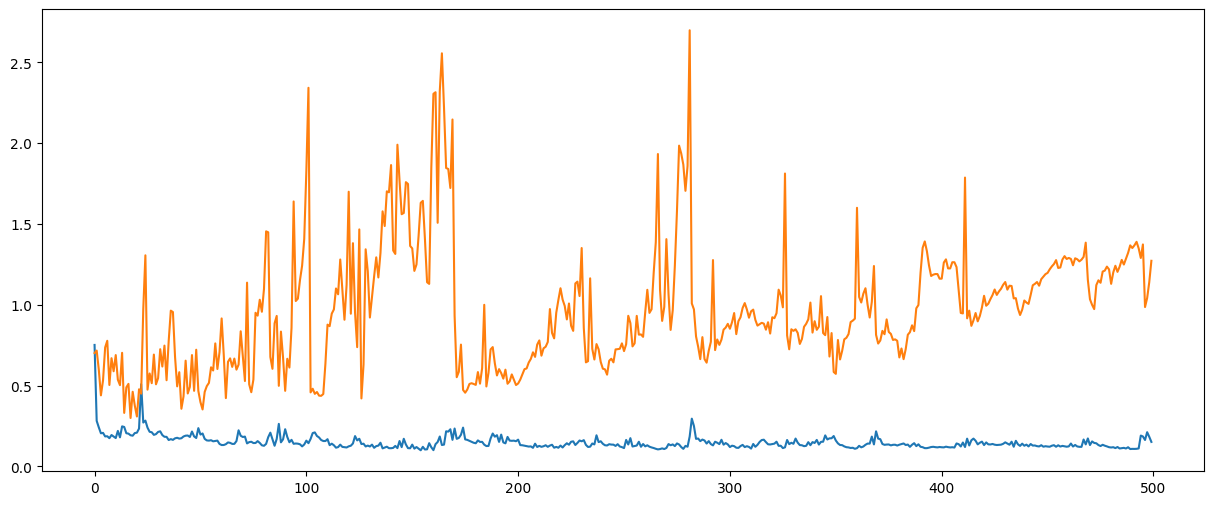

In [ ]:
# Also now let's plot the loss and val_loss to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

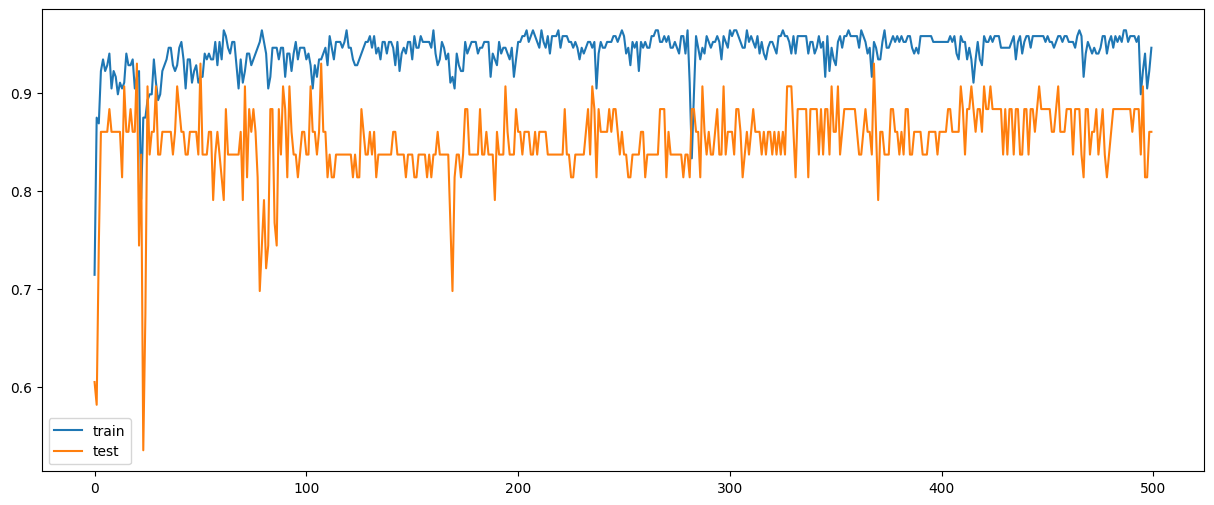

In [22]:
# Now let's plot the accuracy and val_accuracy to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

In [ ]:
# As we can see that the loss of the validation set at some point afterwards is increasing that to jaggered in nature 
# Also note that the loss is greatly of the validation set meaning that the model is overfitting which can also be seen in the accuracy
# comparission of both as above.